# Creating ANN to Predict Output of Function sin(x)

### Creating the data

In [25]:
import pandas as pd
import random
from math import sin
from matplotlib import pyplot as plt

In [82]:
someList = []
random.seed(1)

for i in range(1000):
    x = random.random() * 4
    # y = sin(x)
    y = sin(x) + random.random() * 0.5 - 0.25
    someList.append([x, y])

In [81]:
x = 0
someList = []
for i in range(1000):
    x = x + 4/1000
    y = sin(x)
    someList.append([x, y])

In [83]:
df = pd.DataFrame(someList)
df.columns = ['x', 'y']
df.head()

,x,y
0,0.537457,0.685670
1,3.055098,-0.036079
2,1.981740,0.891490
3,2.606372,0.654393
4,0.375438,0.130854


### Getting and plotting the data

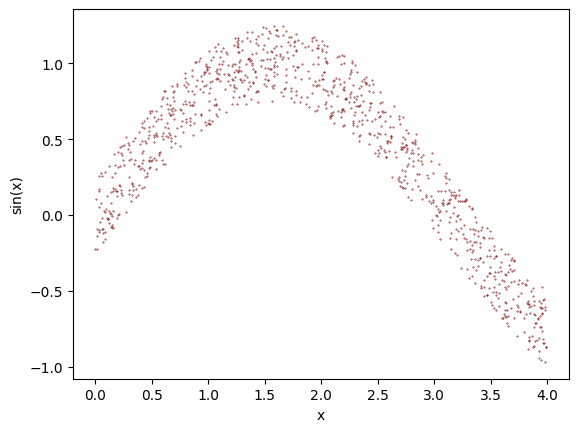

In [84]:
plt.scatter(df['x'], df['y'], color = 'maroon', marker = '.', s = 0.5)
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.show()

### Data set split

In [85]:
from sklearn.model_selection import train_test_split

In [86]:
X_train, X_test, y_train, y_test = train_test_split(df['x'], df['y'], train_size = 0.8, shuffle = True)

### Creating a network model

In [87]:
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

In [98]:
model = Sequential()
model.add(Dense(4, input_dim = 1, activation = 'tanh'))
model.add(Dense(5, activation = 'tanh'))
model.add(Dense(1, activation = 'linear'))

In [99]:
model.compile(loss = 'mse', optimizer = 'adam')

In [100]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 4)                 8         
                                                                 
 dense_10 (Dense)            (None, 5)                 25        
                                                                 
 dense_11 (Dense)            (None, 1)                 6         
                                                                 
Total params: 39 (156.00 Byte)
Trainable params: 39 (156.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [101]:
early_stop = EarlyStopping(monitor = 'loss', patience = 2, verbose = 1)

### Fit the model

In [104]:
history = model.fit(X_train, y_train, epochs = 10, batch_size = 1, callbacks = [early_stop])

Epoch 1/10
800/800 [==============================] - 3s 4ms/step - loss: 0.0224
Epoch 2/10
800/800 [==============================] - 4s 5ms/step - loss: 0.0218
Epoch 3/10
800/800 [==============================] - 3s 4ms/step - loss: 0.0219
Epoch 4/10
800/800 [==============================] - 3s 4ms/step - loss: 0.0216
Epoch 5/10
800/800 [==============================] - 3s 4ms/step - loss: 0.0219
Epoch 6/10
800/800 [==============================] - 3s 4ms/step - loss: 0.0221
Epoch 6: early stopping


### History

In [38]:
print(history.history)

{'loss': [0.18626391887664795, 0.10333330184221268, 0.04501909762620926, 0.012236212380230427, 0.0042472220957279205, 0.001823815400712192, 0.0008182864403352141, 0.0005245237261988223, 0.00048731121933087707, 0.0004221904673613608]}


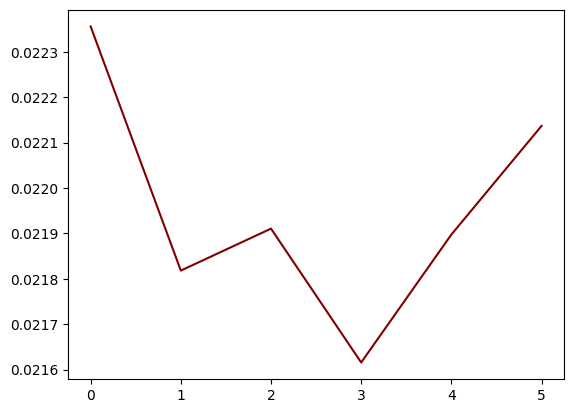

In [105]:
plt.plot(history.history['loss'], color = 'maroon', label = 'Historical loss in training')
plt.show()

### Accuracy

In [106]:
train_accuracy = model.evaluate(X_train, y_train)
test_accuracy = model.evaluate(X_test, y_test)

7/7 [==============================] - 0s 3ms/step - loss: 0.0210


### Make predictions

In [107]:
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

25/25 [==============================] - 0s 5ms/step


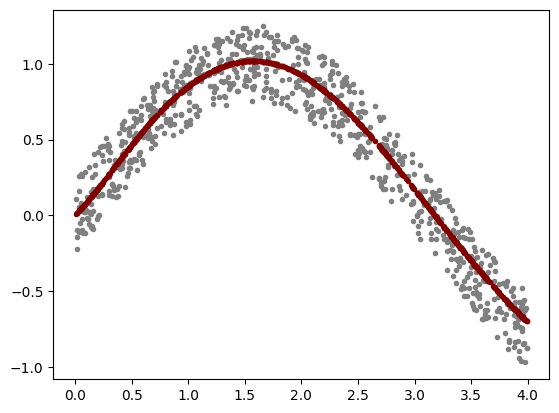

In [108]:
plt.scatter(X_train, y_train, marker = '.', color = 'grey')
plt.scatter(X_train, y_pred_train, marker = '.', color = 'maroon')
plt.show()

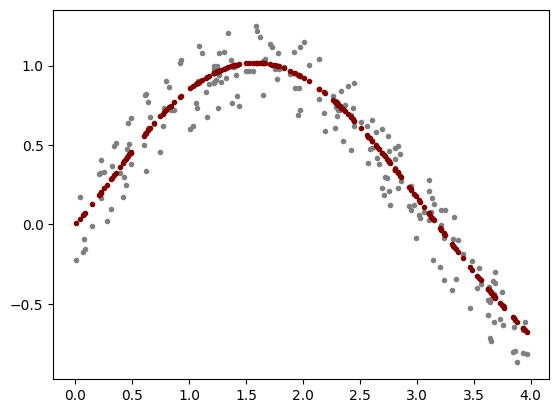

In [109]:
plt.scatter(X_test, y_test, marker = '.', color = 'grey')
plt.scatter(X_test, y_pred, marker = '.', color = 'maroon')
plt.show()

### Testing outside the training area

In [44]:
x = 5
someList = []
for i in range(100):
    x = x + 4/100
    y = sin(x)
    someList.append([x, y])

In [45]:
df = pd.DataFrame(someList)
df.columns = ['x', 'y']
df.head()

,x,y
0,5.04,-0.946814
1,5.08,-0.933189
2,5.12,-0.918070
3,5.16,-0.901484
4,5.20,-0.883455


In [46]:
X_test = df['x']
y_test = df['y']

In [47]:
y_pred = model.predict(X_test)

4/4 [==============================] - 0s 2ms/step


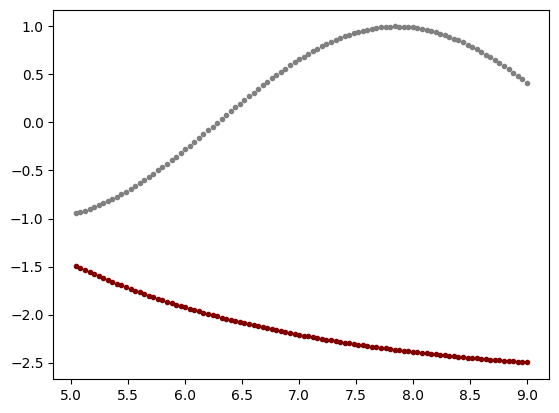

In [48]:
plt.scatter(X_test, y_test, marker = '.', color = 'grey')
plt.scatter(X_test, y_pred, marker = '.', color = 'maroon')
plt.show()

The model only works well on the area it was trained in.